우주비행사 이미지를 불러오고 5가지 왜곡을 생성 중입니다...
[(b) Gaussian Noise] SSIM: 0.637 | FSIM: 0.903 | VIF: 0.340
[(c) Correlated Noise] SSIM: 0.974 | FSIM: 0.988 | VIF: 0.816
[(d) Denoising Artifacts] SSIM: 0.751 | FSIM: 0.902 | VIF: 0.342
[(e) JPEG Compression] SSIM: 0.884 | FSIM: 0.948 | VIF: 0.443
[(f) Transmission Error] SSIM: 0.823 | FSIM: 0.903 | VIF: 0.402


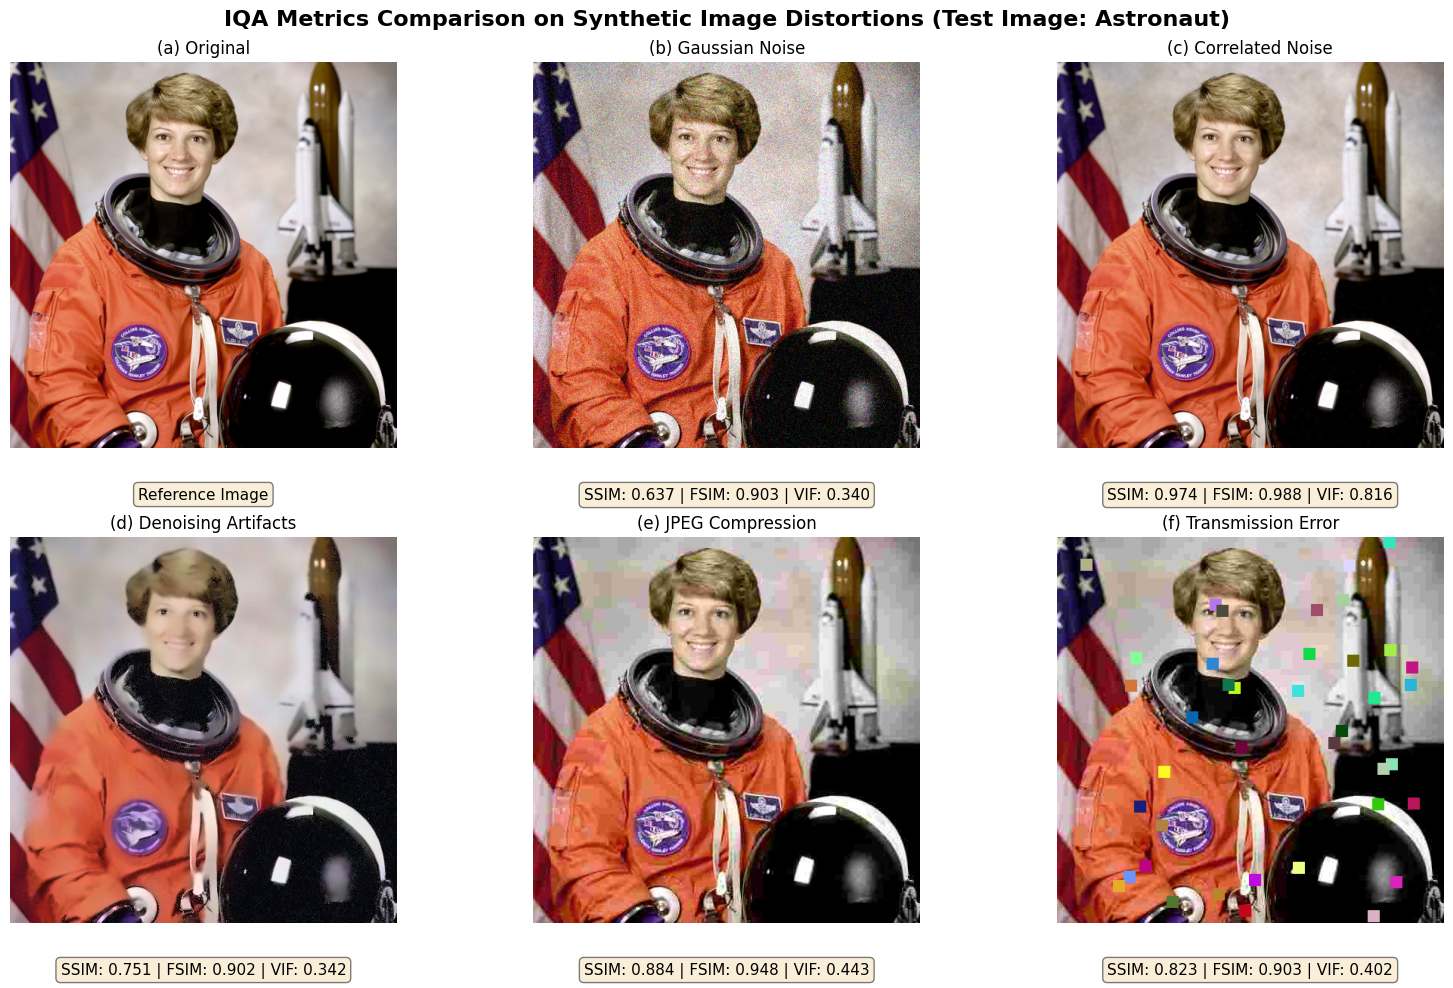

In [4]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from skimage import data, util
from torchvision.transforms.functional import to_tensor
from piq import ssim, fsim, vif_p

# ==========================================
# 1. 평가를 위한 보조 함수
# ==========================================
def numpy_to_tensor(img_np):
    tensor = to_tensor(img_np).unsqueeze(0).float()
    return tensor

def calculate_metrics(ref_tensor, dist_tensor):
    val_ssim = ssim(dist_tensor, ref_tensor, data_range=1.).item()
    val_fsim = fsim(dist_tensor, ref_tensor, data_range=1., chromatic=True).item()
    val_vif = vif_p(dist_tensor, ref_tensor, data_range=1.).item()
    return val_ssim, val_fsim, val_vif

# ==========================================
# 2. 이미지 준비 및 TID2008 왜곡 5종 생성
# ==========================================
print("우주비행사 이미지를 불러오고 5가지 왜곡을 생성 중입니다...")
# 사람의 얼굴과 질감이 포함된 우주비행사 이미지 사용
img_original = data.astronaut() 

# (b) 가산적 가우시안 노이즈 (Additive Gaussian Noise)
# 전체적으로 지글거리는 백색 잡음 추가
img_gaussian = util.random_noise(img_original, mode='gaussian', var=0.01)
img_gaussian = (img_gaussian * 255).astype(np.uint8)

# (c) 공간 상관 노이즈 (Spatially Correlated Noise)
# 노이즈 자체에 블러를 먹여서 뭉치게 만든 뒤 이미지에 더함 (얼룩덜룩한 느낌)
noise = np.random.normal(0, 30, img_original.shape)
blurred_noise = gaussian_filter(noise, sigma=2)
img_corr = np.clip(img_original + blurred_noise, 0, 255).astype(np.uint8)

# (d) 디노이징 왜곡 (Denoising Artifacts)
# 노이즈를 강하게 주고, 이를 디노이징 알고리즘(NLM)으로 억지로 밀어버림 (수채화/플라스틱 현상)
noisy_for_denoise = np.clip(img_original + np.random.normal(0, 40, img_original.shape), 0, 255).astype(np.uint8)
img_denoised = cv2.fastNlMeansDenoisingColored(noisy_for_denoise, None, h=25, hColor=25, templateWindowSize=7, searchWindowSize=21)

# (e) JPEG 압축 왜곡 (JPEG Compression)
# 화질(Quality)을 10으로 아주 낮게 설정하여 강제 압축 (블록킹 현상 발생)
img_bgr = cv2.cvtColor(img_original, cv2.COLOR_RGB2BGR)
_, encoded_img = cv2.imencode('.jpg', img_bgr, [int(cv2.IMWRITE_JPEG_QUALITY), 10])
img_jpeg = cv2.imdecode(encoded_img, 1)
img_jpeg = cv2.cvtColor(img_jpeg, cv2.COLOR_BGR2RGB)

# (f) 전송 오류 (Transmission Errors)
# JPEG 압축 이미지 위에 데이터를 잃어버린 것처럼 무작위 컬러 블록(에러)을 생성
img_error = img_jpeg.copy()
for _ in range(40): # 40개의 에러 블록 생성
    x, y = np.random.randint(0, img_original.shape[1]-16), np.random.randint(0, img_original.shape[0]-16)
    img_error[y:y+16, x:x+16] = np.random.randint(0, 256, 3)

# ==========================================
# 3. 점수 계산 및 시각화
# ==========================================
images = {
    "(a) Original": img_original,
    "(b) Gaussian Noise": img_gaussian,
    "(c) Correlated Noise": img_corr,
    "(d) Denoising Artifacts": img_denoised,
    "(e) JPEG Compression": img_jpeg,
    "(f) Transmission Error": img_error
}

ref_tensor = numpy_to_tensor(img_original)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("IQA Metrics Comparison on Synthetic Image Distortions (Test Image: Astronaut)", fontsize=16, fontweight='bold')
axes = axes.ravel()

for i, (title, img) in enumerate(images.items()):
    dist_tensor = numpy_to_tensor(img)
    
    if i == 0:
        score_text = "Reference Image"
    else:
        val_ssim, val_fsim, val_vif = calculate_metrics(ref_tensor, dist_tensor)
        score_text = f"SSIM: {val_ssim:.3f} | FSIM: {val_fsim:.3f} | VIF: {val_vif:.3f}"
        print(f"[{title}] {score_text}")

    axes[i].imshow(img)
    axes[i].set_title(title, fontsize=12)
    axes[i].axis('off')
    axes[i].text(0.5, -0.1, score_text, transform=axes[i].transAxes, 
                 fontsize=11, ha='center', va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# 📊 [Experiment] IQA Metric Performance Analysis on Synthetic Distortions
> **Note:** This experiment evaluates the robustness and characteristics of three widely used Image Quality Assessment (IQA) metrics—**SSIM, FSIMc, and VIF**. Five distinct types of synthetic distortions were programmatically applied to a standard test image (`Astronaut`) to observe how each metric penalizes different forms of visual degradation.

### 1. Comparative Results Table
| Distortion Type | Visual Characteristics | SSIM | FSIMc | VIF |
| :--- | :--- | :---: | :---: | :---: |
| **(A) Gaussian Noise** | Additive high-frequency white noise | 0.637 | **0.903** | 0.340 |
| **(B) Correlated Noise** | Spatially blurred / clumpy noise | 0.974 | **0.988** | 0.816 |
| **(C) Denoising Artifacts** | Over-smoothed texture, "plastic" look | 0.751 | **0.902** | 0.342 |
| **(D) JPEG Compression** | Blocking & ringing artifacts | 0.884 | **0.948** | 0.443 |
| **(E) Transmission Error** | Random color blocks (False edges) | 0.823 | **0.903** | 0.402 |

---

### 2. Deep Dive & Insights

#### 🔹 FSIMc: Structural Robustness (Contrast & Noise Invariance)
Across all distortion types, **FSIMc consistently maintains high scores (above 0.90)**. This confirms that the **Phase Congruency (PC)** feature successfully extracts the "structural backbone" of the image. Even when the image is heavily degraded by noise or over-smoothing, FSIMc recognizes that the overall shapes and contours remain intact, mimicking the human visual system's macro-level understanding.

#### 🔹 VIF: Strict Information Fidelity Penalty
VIF exhibits the most dramatic sensitivity, dropping to the **0.30~0.40 range** under heavy noise or blurring. Because VIF measures the **statistical loss of high-frequency natural information** rather than just shape preservation, it severely penalizes distortions that disrupt the image's original texture and micro-details.

#### 🔹 The "False Edge" Vulnerability (Transmission Error)
In the **Transmission Error (E)** scenario, FSIMc drops to **0.903**—a noticeable degradation compared to the clean JPEG compression it was built upon (0.948). The randomly generated color blocks create strong, artificial contrast boundaries. Because FSIM relies heavily on gradient magnitude and phase congruency, these "false edges" confuse its structural weighting map, revealing a known vulnerability of edge-based metrics to localized structural anomalies.

#### 🔹 Human Perception Alignment (Correlated vs. Gaussian Noise)
All three metrics score the **Correlated Noise (B)** much higher than the **Gaussian Noise (A)**. This strongly aligns with human psychology; our visual system efficiently masks low-frequency, clumpy noise, finding it significantly less distracting than sharp, high-frequency white noise.